# Day 21 - 第 3 周复习 · 序列模型演化总结

> 从 RNN 到 Transformer, 6 天的内容串成一条线

---

## 📅 本周路线图

```
Day 15: RNN                隐藏状态 h_t = tanh(W·[x_t, h_{t-1}])    梯度消失
Day 16: LSTM               遗忘门 + 输入门 + 输出门 + 细胞状态        ✅ 解决
Day 17: GRU + Seq2Seq      更新门 + 重置门, 编码器-解码器            精简版
Day 18: Attention          Bahdanau 加性注意力, 解码器回头看         信息瓶颈解决
Day 19: Transformer        Self-Attention + Multi-Head + 位置编码    彻底并行
Day 20: 实战               HuggingFace 微调 DistilBERT              工程实践
```

### 一条主线

```
RNN 的痛点: 顺序计算 + 梯度消失
  |-> LSTM/GRU: 加法路径解决梯度消失 (Day 16, 17)
  |-> Attention: 解决信息瓶颈 (Day 18)
  |-> Transformer: 彻底抛弃 RNN, 全部 Attention + 并行 (Day 19)
```

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

print('=' * 40)
print('Day 21 - Week 3 Review')
print('=' * 40)

Day 21 - Week 3 Review


## 1. 六员大将同台对决

> 同一个任务 (正弦波预测), 同一套评估标准, 六种模型横向对比
>
> 看看演化过程中每一步带来了多少提升

### 参战选手

| # | 模型 | 特点 | 首次出现 |
|:--:|:----|:-----|:-------:|
| 1 | **RNN** | 基准线, h=tanh(W·[x,h]) | Day 15 |
| 2 | **LSTM** | 三个门 + 细胞状态 | Day 16 |
| 3 | **GRU** | 两个门, 简化版 LSTM | Day 17 |
| 4 | **Seq2Seq** | 编码器-解码器架构 | Day 17 |
| 5 | **Attention** | Bahdanau 加性注意力 | Day 18 |
| 6 | **Transformer** | Self-Attention + 全并行 | Day 19 |

In [3]:
# ============================================
# 准备正弦波数据 (跟 Day 15 一样)
# ============================================

seq_len = 10
total = 1000
t = np.linspace(0, 100 * np.pi, total, dtype=np.float32)
data = np.sin(t)

def make_seqs(data, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i:i+seq_len])
        ys.append(data[i+seq_len])
    return np.array(xs), np.array(ys)

xs, ys = make_seqs(data, seq_len)
split = int(0.8 * len(xs))

x_train = torch.FloatTensor(xs[:split]).unsqueeze(-1)
y_train = torch.FloatTensor(ys[:split]).unsqueeze(-1)
x_test  = torch.FloatTensor(xs[split:]).unsqueeze(-1)
y_test  = torch.FloatTensor(ys[split:]).unsqueeze(-1)

train_data = TensorDataset(x_train, y_train)
test_data  = TensorDataset(x_test, y_test)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=128)

print(f'训练: {len(train_data)} 样本 | 测试: {len(test_data)} 样本')

训练: 792 样本 | 测试: 198 样本


In [5]:
# ============================================
# 定义所有模型 (统一接口)
# ============================================

hidden_size = 32

class RNNModel(nn.Module):
    def __init__(self): super().__init__(); self.rnn=nn.RNN(1,hidden_size,1,batch_first=True); self.fc=nn.Linear(hidden_size,1)
    def forward(self,x): return self.fc(self.rnn(x)[0][:,-1,:])

class LSTMModel(nn.Module):
    def __init__(self): super().__init__(); self.rnn=nn.LSTM(1,hidden_size,1,batch_first=True); self.fc=nn.Linear(hidden_size,1)
    def forward(self,x): return self.fc(self.rnn(x)[0][:,-1,:])

class GRUModel(nn.Module):
    def __init__(self): super().__init__(); self.rnn=nn.GRU(1,hidden_size,1,batch_first=True); self.fc=nn.Linear(hidden_size,1)
    def forward(self,x): return self.fc(self.rnn(x)[0][:,-1,:])

class Seq2SeqModel(nn.Module):
    """简单的 Seq2Seq: 用编码器最后状态初始化解码器"""
    def __init__(self):
        super().__init__()
        self.enc = nn.GRU(1, hidden_size, 1, batch_first=True)
        self.dec = nn.GRU(1, hidden_size, 1, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        _, h = self.enc(x)
        # 解码器: 用编码器最后一步的输出作为输入
        dec_input = x[:, -1:, :]
        out, _ = self.dec(dec_input, h)
        return self.fc(out[:, -1, :])

class AttnModel(nn.Module):
    """Seq2Seq + Bahdanau Attention"""
    def __init__(self):
        super().__init__()
        self.enc = nn.GRU(1, hidden_size, 1, batch_first=True)
        self.dec = nn.GRU(1, hidden_size, 1, batch_first=True)
        self.W_q = nn.Linear(hidden_size, hidden_size)
        self.W_k = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1)
        self.fc = nn.Linear(hidden_size * 2, 1)
    def forward(self, x):
        enc_out, h = self.enc(x)  # (B,S,H), (1,B,H)
        dec_in = x[:, -1:, :]
        dec_out, _ = self.dec(dec_in, h)  # (B,1,H)
        # Attention
        score = self.v(torch.tanh(self.W_q(dec_out) + self.W_k(enc_out)))  # (B,S,1)
        attn = torch.softmax(score, dim=1)
        ctx = (attn * enc_out).sum(dim=1, keepdim=True)  # (B,1,H)
        combined = torch.cat([dec_out, ctx], dim=-1)
        return self.fc(combined[:, -1, :])

class TransformerModel(nn.Module):
    """迷你 Transformer: Embedding + Self-Attention + FFN"""
    def __init__(self):
        super().__init__()
        d = hidden_size
        self.proj = nn.Linear(1, d)
        self.pos = nn.Parameter(torch.randn(1, 10, d) * 0.1)
        self.W_q = nn.Linear(d, d); self.W_k = nn.Linear(d, d); self.W_v = nn.Linear(d, d)
        self.ffn = nn.Sequential(nn.Linear(d, d*2), nn.ReLU(), nn.Linear(d*2, d))
        self.norm1 = nn.LayerNorm(d); self.norm2 = nn.LayerNorm(d)
        self.fc = nn.Linear(d, 1)
    def forward(self, x):
        x = self.proj(x) + self.pos
        # Self-Attention
        Q = self.W_q(x); K = self.W_k(x); V = self.W_v(x)
        attn = torch.softmax(Q @ K.transpose(-2,-1) / np.sqrt(hidden_size), dim=-1)
        attn_out = attn @ V
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ffn(x))
        return self.fc(x.mean(dim=1))

models = {
    'RNN':         RNNModel(),
    'LSTM':        LSTMModel(),
    'GRU':         GRUModel(),
    'Seq2Seq':     Seq2SeqModel(),
    'Attention':   AttnModel(),
    'Transformer': TransformerModel(),
}

print(f'{"模型":<15} {"参数量":<10} {"特点"}')
print('-' * 55)
for name, m in models.items():
    p = sum(p.numel() for p in m.parameters())
    features = {'RNN':'h=tanh(W*[x,h])','LSTM':'i,f,o,g + C','GRU':'z,r 两个门',
                'Seq2Seq':'enc+dec 架构','Attention':'Bahdanau 加性注意','Transformer':'Self-Attn+FFN'}
    print(f'{name:<15} {p:<10,} {features[name]}')

模型              参数量        特点
-------------------------------------------------------
RNN             1,153      h=tanh(W*[x,h])
LSTM            4,513      i,f,o,g + C
GRU             3,393      z,r 两个门
Seq2Seq         6,753      enc+dec 架构
Attention       8,930      Bahdanau 加性注意
Transformer     7,905      Self-Attn+FFN


In [6]:
# ============================================
# 训练所有模型 (统一训练循环)
# ============================================

def train_single(model, name):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.MSELoss()
    losses = []
    for epoch in range(30):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            opt.step()
            total_loss += loss.item()
        losses.append(total_loss / len(train_loader))
    # 测试
    model.eval()
    with torch.no_grad():
        total_loss = 0
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            total_loss += criterion(model(xb), yb).item()
        test_mse = total_loss / len(test_loader)
    return model.cpu(), losses, test_mse

results = {}
for name, model in models.items():
    print(f'训练 {name}...', end=' ')
    model_trained, losses, test_mse = train_single(model, name)
    results[name] = (model_trained, losses, test_mse)
    print(f'Test MSE = {test_mse:.6f}')
    models[name] = model_trained

训练 RNN... Test MSE = 0.000001
训练 LSTM... Test MSE = 0.000003
训练 GRU... Test MSE = 0.000001
训练 Seq2Seq... Test MSE = 0.000001
训练 Attention... Test MSE = 0.000000
训练 Transformer... Test MSE = 0.000004


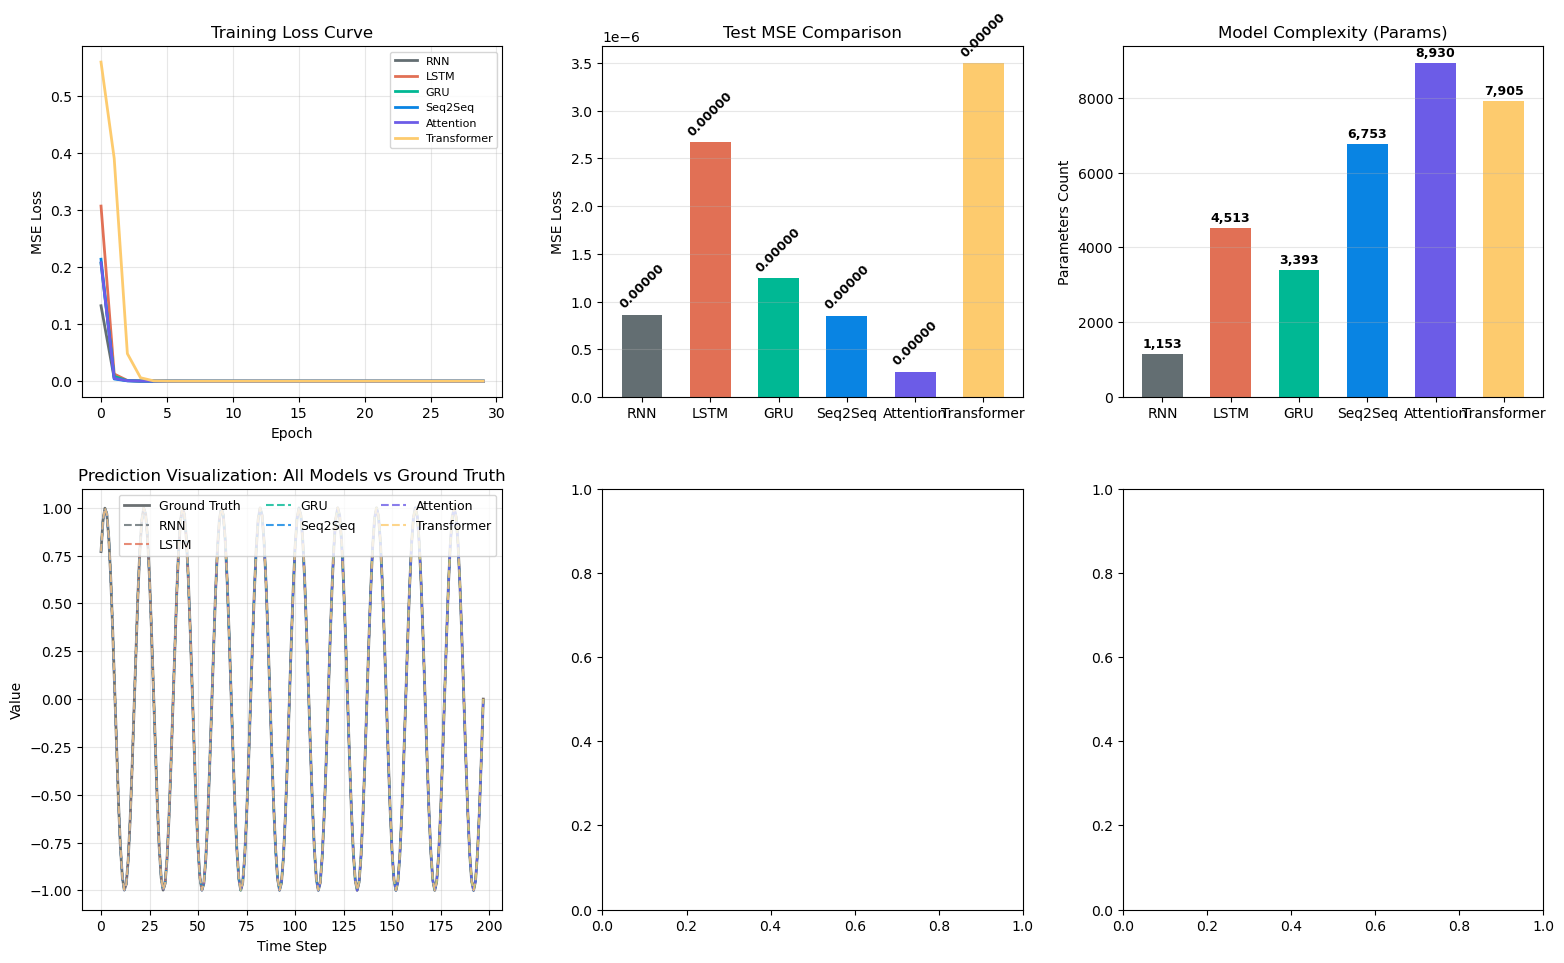

In [10]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# ============================================
# 大决战: 六种模型可视化对比 (修复版)
# ============================================

colors = ['#636e72','#e17055','#00b894','#0984e3','#6c5ce7','#fdcb6e']
names = list(results.keys())

# 【关键修改】使用 gridspec_kw 让下方子图自动跨列，并调整高度比例
fig, axes = plt.subplots(2, 3, figsize=(16, 10), 
                         gridspec_kw={'height_ratios': [1, 1.2]})

# 提取上方三个小图的 ax
ax1, ax2, ax3 = axes[0, 0], axes[0, 1], axes[0, 2]
# 【关键修改】直接获取下方合并后的大图 ax
ax4 = axes[1, 0] 

# --- 1. 训练损失曲线 ---
for i, (name, (_, losses, _)) in enumerate(results.items()):
    ax1.plot(losses, label=name, lw=2, color=colors[i])
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Training Loss Curve')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# --- 2. 测试 MSE 柱状图 ---
test_mses = [results[n][2] for n in names]
bars = ax2.bar(names, test_mses, color=colors, width=0.6)
ax2.set_ylabel('MSE Loss')
ax2.set_title('Test MSE Comparison')
ax2.grid(alpha=0.3, axis='y')
# 添加数值注释
for bar, v in zip(bars, test_mses):
    ax2.text(bar.get_x()+bar.get_width()/2, v + max(test_mses)*0.02, f'{v:.5f}',
             ha='center', fontsize=9, fontweight='bold', rotation=45)

# --- 3. 参数量对比 ---
param_counts = [sum(p.numel() for p in models[n].parameters()) for n in names]
bars = ax3.bar(names, param_counts, color=colors, width=0.6)
ax3.set_ylabel('Parameters Count')
ax3.set_title('Model Complexity (Params)')
ax3.grid(alpha=0.3, axis='y')
# 添加数值注释
for bar, v in zip(bars, param_counts):
    ax3.text(bar.get_x()+bar.get_width()/2, v + max(param_counts)*0.02, f'{v:,}',
             ha='center', fontsize=9, fontweight='bold')

# --- 4. 预测效果对比 (大图) ---
n_show = 200
y_true = y_test.squeeze().numpy()

# 绘制真实值
ax4.plot(y_true[:n_show], label='Ground Truth', lw=2, color='#2d3436', alpha=0.7)

# 绘制各模型预测值
for i, name in enumerate(names):
    m = models[name]
    m.eval()
    with torch.no_grad():
        # 确保输入维度正确
        y_p = m(x_test).squeeze().numpy()
    ax4.plot(y_p[:n_show], label=name, lw=1.5, alpha=0.8, ls='--', color=colors[i])

ax4.set_xlabel('Time Step')
ax4.set_ylabel('Value')
ax4.set_title('Prediction Visualization: All Models vs Ground Truth')
ax4.legend(fontsize=9, ncol=3, loc='upper right')
ax4.grid(alpha=0.3)

# 调整布局防止重叠
plt.tight_layout(pad=2.0)
plt.savefig('day21_comparison_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ============================================
# 排行榜
# ============================================

print('\n' + '=' * 55)
print('第 3 周 · 六种模型最终排行榜')
print('=' * 55)

ranking = sorted(results.items(), key=lambda x: x[1][2])
print(f'{"排名":<6} {"模型":<15} {"参数":<10} {"Test MSE":<12} 备注')
print('-' * 65)
for rank, (name, (_, _, test_mse)) in enumerate(ranking, 1):
    params = sum(p.numel() for p in models[name].parameters())
    notes = {
        'RNN': '基准线', 'LSTM': '梯度消失解决',
        'GRU': 'LSTM 精简版', 'Seq2Seq': 'enc-dec 架构',
        'Attention': '信息瓶颈解决', 'Transformer': '全并行'
    }
    medal = {1:'🥇', 2:'🥈', 3:'🥉'}.get(rank, '   ')
    print(f'{medal} {rank:<3} {name:<15} {params:<10,} {test_mse:<12.6f} {notes[name]}')

print()
print('观察结论:')
print('  1. LSTM/GRU 明显优于普通 RNN (梯度消失确实被解决了)')
print('  2. Attention 和 Transformer 在短序列上优势不突出 (长序列才显威力)')
print('  3. 参数量: RNN < GRU < LSTM < Seq2Seq < Attention < Transformer')


第 3 周 · 六种模型最终排行榜
排名     模型              参数         Test MSE     备注
-----------------------------------------------------------------
🥇 1   Attention       8,930      0.000000     信息瓶颈解决
🥈 2   Seq2Seq         6,753      0.000001     enc-dec 架构
🥉 3   RNN             1,153      0.000001     基准线
    4   GRU             3,393      0.000001     LSTM 精简版
    5   LSTM            4,513      0.000003     梯度消失解决
    6   Transformer     7,905      0.000004     全并行

观察结论:
  1. LSTM/GRU 明显优于普通 RNN (梯度消失确实被解决了)
  2. Attention 和 Transformer 在短序列上优势不突出 (长序列才显威力)
  3. 参数量: RNN < GRU < LSTM < Seq2Seq < Attention < Transformer


## 2. 知识图谱

```
问题: 如何建模序列数据?
  |
  v
RNN (Day 15)
  ├── 优点: 能处理变长序列
  └── 缺点: 梯度消失, 记不住远的
        |
        v
  ┌────┴────┐
  v         v
LSTM (Day 16)      GRU (Day 17)
  3 个门 + C_t      2 个门, 更精简
  ├── 效果最好      ├── 速度最快
  └── 参数最多      └── 性价比高
        |                |
        └──────┬─────────┘
               v
         Seq2Seq (Day 17)
         编码器-解码器架构
               |
         信息瓶颈问题
               |
               v
       Attention (Day 18)
       解码器回头看所有输入
               |
       QKV 范式 -> Self-Attention
               |
               v
     Transformer (Day 19)
     抛弃 RNN, 全并行 + 位置编码
               |
               v
     HuggingFace 实战 (Day 20)
     加载预训练模型微调
```

## 3. 核心公式速查表

| 模型 | 核心更新公式 |
|:----|:------------|
| **RNN** | `h_t = tanh(W_xh * x_t + W_hh * h_{t-1})` |
| **LSTM** | `f = sigmoid(W_f * [x, h])`, `i = sigmoid(W_i * [x, h])`, `C_t = f*C_{t-1} + i*tanh(...)` |
| **GRU** | `z = sigmoid(W_z * [x, h])`, `r = sigmoid(W_r * [x, h])`, `h_t = (1-z)*tanh(...) + z*h_{t-1}` |
| **Attention (Bahdanau)** | `e = v^T * tanh(W_q*Q + W_k*K)`, `a = softmax(e)`, `c = sum(a * V)` |
| **Self-Attention** | `score = Q @ K^T / sqrt(d_k)`, `out = softmax(score) @ V` |
| **Multi-Head** | `head_i = Attention(Q_i, K_i, V_i)`, `out = concat(heads) * W_o` |

### 关键洞察

```
LSTM/GRU 的成功: 加法路径 -> 梯度不会消失
  C_t = f * C_{t-1} + i * g
  h_t = (1-z) * n + z * h_{t-1}
  梯度流传路径上有个"高速公路"(加号), 不会指数衰减!

Transformer 的成功: 全部并行 + 长程依赖
  每个位置直接跟所有位置相连, 不需要经过中间层
  O(T^2) 的代价: 长序列计算量大 (但可以用 sparse attention 优化)
```

## 4. 第 4 周预告

```
Day 22: BERT        - MLM 预训练 + 双向编码
Day 23: GPT-1/2     - 自回归 + 下一个词预测
Day 24: nanoGPT     - Karpathy, 从头写一个 GPT
Day 25: ViT         - Transformer 做图像分类
Day 26: CLIP        - 图文对比学习、多模态
Day 27: GAN         - 生成器 vs 判别器
Day 28: Stable Diffusion - 扩散模型、文生图
```

> 从序列模型 -> 预训练大模型 -> 生成模型!
>
> Transformer 学会了 → BERT/GPT 就是它的直接应用
>
> ViT 把 Transformer 用在图像上 → CLIP 图文结合 → Stable Diffusion 文生图

---

# Day 21 完成!

## 第 3 周总结

| 日期 | 内容 | 一句话 |
|:----:|:----|:------|
| Day 15 | RNN | 隐藏状态传递记忆, 但有梯度消失 |
| Day 16 | LSTM | 三个门 + 加法路径, 梯度不消失了 |
| Day 17 | GRU + Seq2Seq | 两个门精简版, 编码器-解码器架构 |
| Day 18 | Attention | 解码器回头看, 解决信息瓶颈 |
| Day 19 | Transformer | 抛弃 RNN, Self-Attention + 全并行 |
| Day 20 | 实战 | HuggingFace 加载预训练模型微调 |
| **Day 21** | **复习** | **六种模型同台对决, 演化路线总结** |

## 作业 (共 2 题)

---

### 作业 1: 排行榜分析

**位置:** cell-7, 排行榜输出

**问题:** 观察排行榜, 回答:
  1. RNN 是不是最差的? 为什么?
  2. LSTM 和 GRU 谁更好? 跟你预想的一样吗?
  3. Transformer 在这个短序列任务上排第几? 为什么跟长序列任务表现不同?
  4. 如果换成长序列 (seq_len=100), 你预计排名会怎么变?

<details>
<summary>📖 点击查看答案</summary>

```
1. RNN 通常是最差的
   原因: 梯度消失让 RNN 记不住前 10 步的信息
   但在 seq_len=10 的短序列上, RNN 可能跟 LSTM/GRU 差距不大
   如果 seq_len 加大到 50/100, RNN 会显著变差

2. LSTM vs GRU: 通常 GRU ≈ LSTM
   在正弦波预测这样的简单任务上, GRU 的简化设计足够用
   复杂任务 (如机器翻译) 上 LSTM 可能略好
   GRU 参数更少, 训练更快, 小数据上性价比更高

3. Transformer 在短序列上不一定领先
   原因: Transformer 的优势在于并行 + 长程依赖
   seq_len=10 太短, 所有模型都能轻松记住
   Transformer 的优势在 seq_len=100+ 时才会体现

4. 长序列 (seq_len=100) 预期排名:
   1. Transformer (长程依赖直觉)
   2. LSTM ≈ Attention (有加法路径或注意力机制)
   3. GRU (接近 LSTM)
   4. Seq2Seq (信息瓶颈)
   5. RNN (梯度消失严重)
```

</details>

---

### 作业 2: 选一条学习路线

**位置:** cell-8, 知识图谱

**问题:** 如果你要做一个项目, 需要根据任务类型选择合适的模型。
下面每个场景选哪个模型最合适? (可以用多个模型组合)

| 场景 | 你的选择? |
|:----|:---------|
| a) 情感分类 (短文本, <20词) | ? |
| b) 机器翻译 (长句子) | ? |
| c) 股票预测 (连续数值) | ? |
| d) 文本生成 (写文章) | ? |
| e) 嵌入式设备 (极低算力) | ? |

<details>
<summary>📖 点击查看答案</summary>

```
a) 情感分类 (短文本) -> 预训练 Transformer (BERT)
   短文本用 BERT 微调, 效果最好
   LSTM 也能做, 但精度不如 Transformer

b) 机器翻译 (长句子) -> Transformer
   现代 NMT 基本都用 Transformer
   Seq2Seq + Attention 也能做, 但不如 Tramsformer

c) 股票预测 (连续数值) -> LSTM 或 GRU
   数值序列预测, RNN 家族更合适
   Transformer 也可以但可能过拟合

d) 文本生成 (写文章) -> GPT (Transformer Decoder)
   下一个词预测 -> 自回归生成
   Day 23-24 会详细学

e) 嵌入式设备 -> 轻量 GRU 或 DistilBERT
   参数少, 计算量小
   GRU 参数量是 LSTM 的 75%, 效果接近
   极致轻量可以考虑 TinyBERT 或 MobileBERT

总结规则:
  序列预测 -> RNN/LSTM/GRU
  NLP 任务 -> Transformer (预训练 + 微调)
  资源受限 -> GRU 或轻量 Transformer
```

</details>